In [17]:
import pandas as pd
import math
from matplotlib import pyplot as plt
import numpy as np

***
**Data analysis**
***

In [9]:
data = pd.read_csv('obsinfox.csv')
data

,URL,Title,Fake News,"Places, Dates, People",Facts,Opinions,Subjective,Reported information,Sources Cited,False Information,Insinuation,Exaggeration,Offbeat Title,Annotator
0,https://lesakerfrancophone.fr/la-relation-entr...,La relation entre la technologie et la religion,0,1,1,1,1,0,1,0,0,0,0,rater1
1,https://www.breizh-info.com/2021/01/27/157958/...,"Confinement. Les habitants de Brest, Morlaix e...",0,1,1,0,0,0,1,0,0,0,0,rater1
2,https://reseauinternational.net/la-chine-le-pr...,La Chine : Le premier marché mondial de Smartp...,0,1,1,0,0,0,1,0,0,0,0,rater1
3,https://lezarceleurs.blogspot.com/2021/12/emma...,"Emmanuel à Olivier : « Tiens bon, on les aura ...",1,1,1,1,1,0,0,1,0,1,0,rater1
4,https://lesakerfrancophone.fr/selon-ubs-les-pr...,"Selon UBS, les « propriétés d’assurance tant d...",0,1,1,1,1,0,1,0,0,0,0,rater1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,https://lemediaen442.fr/loi-climat-le-gouverne...,Loi climat : le gouvernement va exempter Amazo...,0,1,1,0,0,0,0,0,1,1,0,rater8
796,https://www.breizh-info.com/2017/11/10/81481/q...,Le QI peut-il être augmenté par l’éducation ? ...,0,1,1,0,0,0,1,0,0,0,0,rater8
797,https://lesmoutonsrebelles.com/secte-sexuelle-...,Secte sexuelle : l’ex-star de Smallville Aliso...,0,1,1,0,0,0,1,0,1,0,0,rater8
798,https://lesalonbeige.fr/sacre-de-charles-iii-p...,Sacre de Charles III par SAR le Prince Charles...,0,1,1,1,1,0,0,0,1,0,0,rater8


In [10]:
data.columns

Index(['URL', 'Title', 'Fake News', 'Places, Dates, People', 'Facts',
       'Opinions', 'Subjective', 'Reported information', 'Sources Cited',
       'False Information', 'Insinuation', 'Exaggeration', 'Offbeat Title',
       'Annotator'],
      dtype='object')

In [11]:
rating_columns = [
    'Fake News', 'Places, Dates, People', 'Facts', 'Opinions', 'Subjective',
    'Reported information', 'Sources Cited', 'False Information', 'Insinuation',
    'Exaggeration', 'Offbeat Title'
]

agreement = data.groupby('URL')[rating_columns].nunique()

# Display the result: for each URL, each cell shows how many different ratings were given.
print("Unique values per rating column by URL:")
print(agreement)

# Optionally, create a column that flags if all rating columns have full agreement
# (i.e. if for every rating column, the number of unique values is 1 for this URL).
agreement['all_agree'] = agreement.eq(1).all(axis=1)

print("\nAgreement summary (all_agree = True means every rating is identical):")
agreement[['all_agree']]

Unique values per rating column by URL:
                                                    Fake News  \
URL                                                             
https://lalettrepatriote.com/deja-marie-en-alge...          2   
https://lalettrepatriote.com/emmanuel-macron-et...          2   
https://lalettrepatriote.com/le-pakistan-menace...          1   
https://lalettrepatriote.com/un-couple-loge-une...          2   
https://lalettrepatriote.com/ursula-von-der-ley...          2   
...                                                       ...   
https://www.profession-gendarme.com/ukraine-la-...          2   
https://www.profession-gendarme.com/ulrike-reis...          1   
https://www.profession-gendarme.com/un-colonel-...          1   
https://www.profession-gendarme.com/un-medecin-...          2   
https://www.profession-gendarme.com/vaccin-anti...          2   

                                                    Places, Dates, People  \
URL                                  

,all_agree
URL,
https://lalettrepatriote.com/deja-marie-en-algerie-il-epouse-une-francaise/,False
https://lalettrepatriote.com/emmanuel-macron-et-giorgia-meloni-appellent-a-soutenir-la-tunisie-pour-contenir-la-pression-migratoire/,False
https://lalettrepatriote.com/le-pakistan-menace-dinterdire-wikipedia/,False
https://lalettrepatriote.com/un-couple-loge-une-famille-de-migrants-36-000-e-de-degats/,False
https://lalettrepatriote.com/ursula-von-der-leyen-menace-les-italiens-a-la-veille-des-elections/,False
...,...
https://www.profession-gendarme.com/ukraine-la-defense-territoriale-entre-en-scene/,False
https://www.profession-gendarme.com/ulrike-reisner-quel-lien-entre-le-vaccin-et-la-guerre-en-ukraine/,False
https://www.profession-gendarme.com/un-colonel-de-gendarmerie-a-la-tete-de-la-spa-pour-ramener-la-paix/,False


In [12]:
def disagreement_indicator(series):
    """
    For a binary (0/1) rating series, computes the disagreement indicator.
    p = proportion of ratings equal to 1.
    The disagreement is defined as: 4 * p * (1 - p)
    which is 0 when everyone agrees (p=0 or 1) and 1 when p=0.5.
    """
    p = series.mean()
    return 4 * p * (1 - p)

# Group the DataFrame by URL and compute disagreement for each rating column
disagreement_df = data.groupby('URL')[rating_columns].agg(disagreement_indicator)
disagreement_df['Overall_Disagreement'] = disagreement_df.mean(axis=1)
print("\nOverall disagreement per URL:")
disagreement_df[['Overall_Disagreement']]


Overall disagreement per URL:


,Overall_Disagreement
URL,
https://lalettrepatriote.com/deja-marie-en-algerie-il-epouse-une-francaise/,0.443182
https://lalettrepatriote.com/emmanuel-macron-et-giorgia-meloni-appellent-a-soutenir-la-tunisie-pour-contenir-la-pression-migratoire/,0.272727
https://lalettrepatriote.com/le-pakistan-menace-dinterdire-wikipedia/,0.340909
https://lalettrepatriote.com/un-couple-loge-une-famille-de-migrants-36-000-e-de-degats/,0.761364
https://lalettrepatriote.com/ursula-von-der-leyen-menace-les-italiens-a-la-veille-des-elections/,0.687500
...,...
https://www.profession-gendarme.com/ukraine-la-defense-territoriale-entre-en-scene/,0.522727
https://www.profession-gendarme.com/ulrike-reisner-quel-lien-entre-le-vaccin-et-la-guerre-en-ukraine/,0.250000
https://www.profession-gendarme.com/un-colonel-de-gendarmerie-a-la-tete-de-la-spa-pour-ramener-la-paix/,0.136364


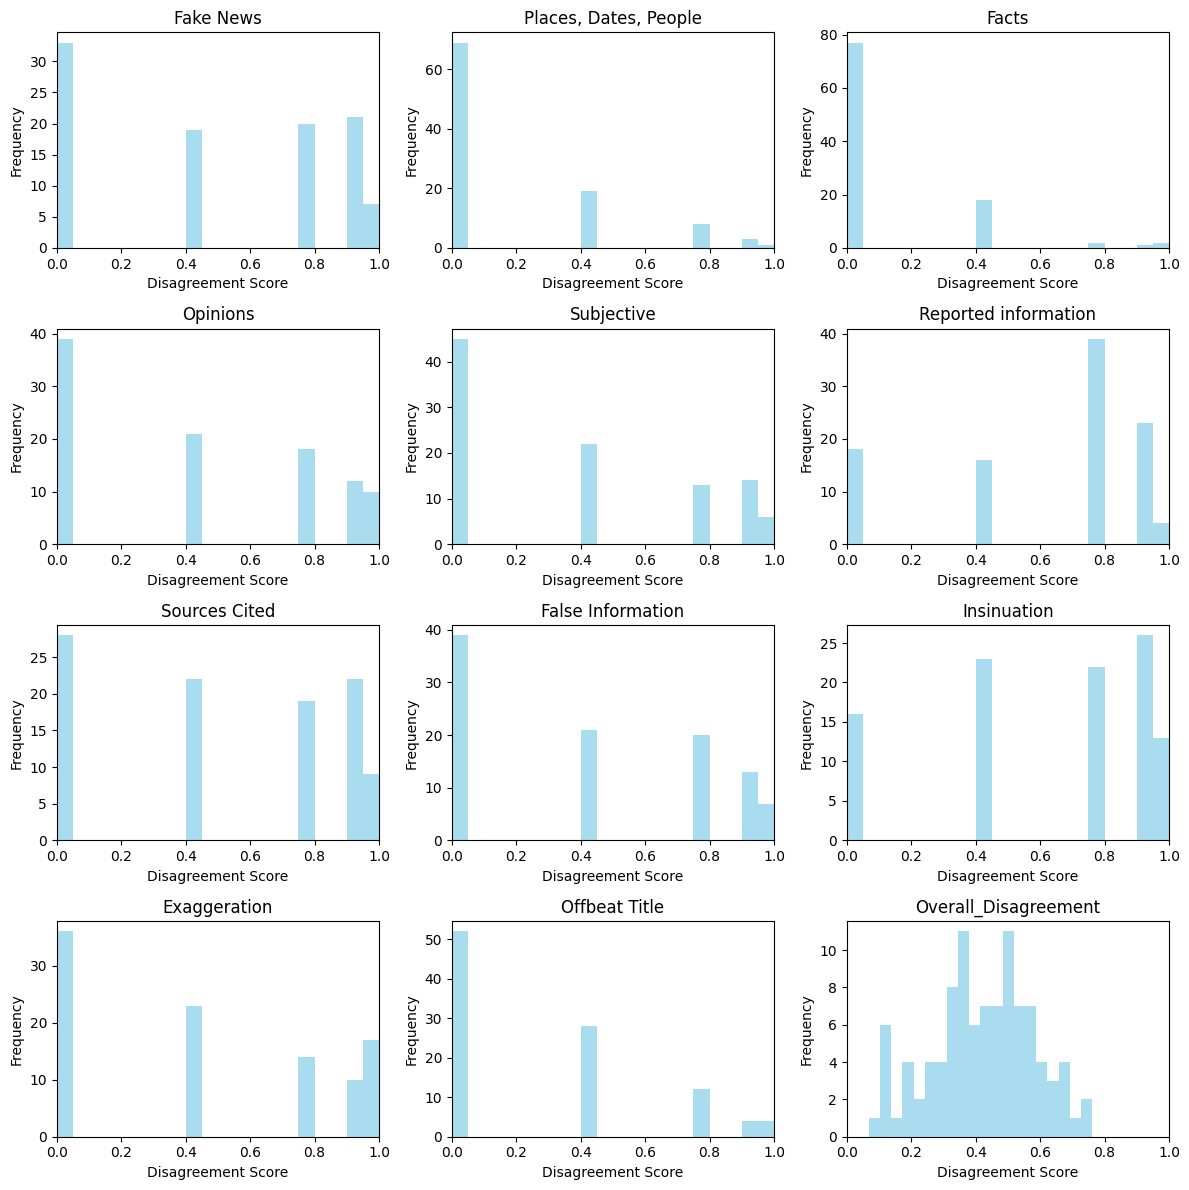

In [33]:
import math
rating_columns = [
    'Fake News', 
    'Places, Dates, People', 
    'Facts', 
    'Opinions', 
    'Subjective', 
    'Reported information', 
    'Sources Cited', 
    'False Information', 
    'Insinuation', 
    'Exaggeration', 
    'Offbeat Title'
]

# And you computed:
# disagreement_df = data.groupby('URL')[rating_columns].agg(disagreement_indicator)

# We'll now plot the distribution of the disagreement score for each category.
categories = disagreement_df.columns  # Same as rating_columns.
n_categories = len(categories)

# Choose grid layout: e.g., 3 columns
ncols = 3
nrows = math.ceil(n_categories / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()  # Flatten so we can iterate over them easily

for i, col in enumerate(categories):
    axes[i].hist(disagreement_df[col], bins=20, color='skyblue', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel("Disagreement Score")
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlim(0, 1)  # Disagreement score ranges from 0 to 1

# If there are any unused subplots, hide them.
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [34]:
disagreement_df

,Fake News,"Places, Dates, People",Facts,Opinions,Subjective,Reported information,Sources Cited,False Information,Insinuation,Exaggeration,Offbeat Title,Overall_Disagreement
URL,,,,,,,,,,,,
https://lalettrepatriote.com/deja-marie-en-algerie-il-epouse-une-francaise/,0.7500,0.0000,0.0,1.0000,0.4375,0.4375,0.4375,0.4375,0.9375,0.4375,0.00,0.443182
https://lalettrepatriote.com/emmanuel-macron-et-giorgia-meloni-appellent-a-soutenir-la-tunisie-pour-contenir-la-pression-migratoire/,0.4375,0.0000,0.0,0.7500,0.0000,0.9375,0.4375,0.0000,0.4375,0.0000,0.00,0.272727
https://lalettrepatriote.com/le-pakistan-menace-dinterdire-wikipedia/,0.0000,0.7500,0.0,0.7500,0.4375,0.9375,0.4375,0.0000,0.4375,0.0000,0.00,0.340909
https://lalettrepatriote.com/un-couple-loge-une-famille-de-migrants-36-000-e-de-degats/,0.7500,0.9375,0.0,0.9375,0.9375,0.4375,1.0000,0.9375,0.9375,0.7500,0.75,0.761364
https://lalettrepatriote.com/ursula-von-der-leyen-menace-les-italiens-a-la-veille-des-elections/,0.9375,0.0000,0.0,0.9375,0.9375,0.9375,0.4375,0.4375,0.9375,1.0000,1.00,0.687500
...,...,...,...,...,...,...,...,...,...,...,...,...
https://www.profession-gendarme.com/ukraine-la-defense-territoriale-entre-en-scene/,0.9375,0.4375,0.0,0.0000,0.9375,0.7500,0.0000,0.7500,0.9375,1.0000,0.00,0.522727
https://www.profession-gendarme.com/ulrike-reisner-quel-lien-entre-le-vaccin-et-la-guerre-en-ukraine/,0.0000,0.0000,0.0,0.4375,0.0000,0.4375,0.0000,0.9375,0.0000,0.9375,0.00,0.250000
https://www.profession-gendarme.com/un-colonel-de-gendarmerie-a-la-tete-de-la-spa-pour-ramener-la-paix/,0.0000,0.0000,0.0,0.7500,0.0000,0.7500,0.0000,0.0000,0.0000,0.0000,0.00,0.136364


Counts for each sum value:
0    188
1    110
2    106
3     72
4     80
5     77
6     81
7    122
8    264
Name: count, dtype: int64


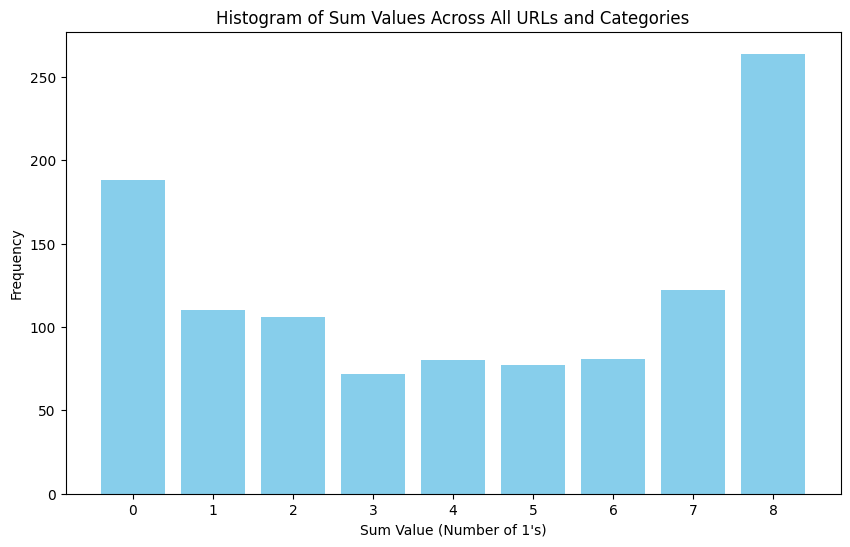

In [35]:
sum_df = data.groupby('URL')[rating_columns].sum()
flat_values = sum_df.values.flatten()
flat_series = pd.Series(flat_values)
counts = flat_series.value_counts().sort_index()

print("Counts for each sum value:")
print(counts)

# Create a histogram using matplotlib.
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='skyblue')
plt.xlabel("Sum Value (Number of 1's)")
plt.ylabel("Frequency")
plt.title("Histogram of Sum Values Across All URLs and Categories")
plt.xticks(np.arange(flat_series.min(), flat_series.max() + 1, 1))
plt.show()

In [36]:
#Modify sum_df so that if the value is 0,1,2,3 it is 0 and if it is strictly above 3 it becomes 1
sum_df = sum_df.applymap(lambda x: 0 if x <= 3 else 1)


C:\Users\mathys.bodelet\AppData\Local\Temp\ipykernel_37940\597863095.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sum_df = sum_df.applymap(lambda x: 0 if x <= 3 else 1)


In [37]:
sum_df
#Modify sum_df to delete row where 'moutons' is in URL
sum_df = sum_df[~sum_df.index.str.contains('moutons')]
#Modify sum_df to delete row wher URL is equal to https://lalettrepatriote.com/ursula-von-der-leyen-menace-les-italiens-a-la-veille-des-elections/
sum_df = sum_df[~sum_df.index.str.contains('https://lalettrepatriote.com/ursula-von-der-leyen-menace-les-italiens-a-la-veille-des-elections/')]
sum_df

,Fake News,"Places, Dates, People",Facts,Opinions,Subjective,Reported information,Sources Cited,False Information,Insinuation,Exaggeration,Offbeat Title
URL,,,,,,,,,,,
https://lalettrepatriote.com/deja-marie-en-algerie-il-epouse-une-francaise/,0,1,1,1,0,0,1,0,1,0,0
https://lalettrepatriote.com/emmanuel-macron-et-giorgia-meloni-appellent-a-soutenir-la-tunisie-pour-contenir-la-pression-migratoire/,0,1,1,0,0,0,1,0,0,0,0
https://lalettrepatriote.com/le-pakistan-menace-dinterdire-wikipedia/,0,1,1,0,0,0,1,0,0,0,0
https://lalettrepatriote.com/un-couple-loge-une-famille-de-migrants-36-000-e-de-degats/,1,1,1,0,0,1,1,0,1,1,0
https://lalettrepatriote.com/ursula-von-der-leyen-non-elue-et-intouchable/,1,1,1,1,1,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
https://www.profession-gendarme.com/ukraine-la-defense-territoriale-entre-en-scene/,0,1,1,1,1,0,1,0,1,1,0
https://www.profession-gendarme.com/ulrike-reisner-quel-lien-entre-le-vaccin-et-la-guerre-en-ukraine/,1,1,1,1,1,0,1,1,1,1,0
https://www.profession-gendarme.com/un-colonel-de-gendarmerie-a-la-tete-de-la-spa-pour-ramener-la-paix/,0,1,1,0,0,0,1,0,0,0,0


In [38]:
counts_0_1 = sum_df.apply(lambda col: pd.Series({'0s': (col == 0).sum(), '1s': (col == 1).sum()}))
counts_0_1

,Fake News,"Places, Dates, People",Facts,Opinions,Subjective,Reported information,Sources Cited,False Information,Insinuation,Exaggeration,Offbeat Title
0s,56,0,0,17,29,79,17,73,37,39,88
1s,37,93,93,76,64,14,76,20,56,54,5


In [39]:
#delete column "Places,Dates,People" and column "Facts" from the dataset
sum_df = sum_df.drop(columns=['Places, Dates, People', 'Facts'])
sum_df

,Fake News,Opinions,Subjective,Reported information,Sources Cited,False Information,Insinuation,Exaggeration,Offbeat Title
URL,,,,,,,,,
https://lalettrepatriote.com/deja-marie-en-algerie-il-epouse-une-francaise/,0,1,0,0,1,0,1,0,0
https://lalettrepatriote.com/emmanuel-macron-et-giorgia-meloni-appellent-a-soutenir-la-tunisie-pour-contenir-la-pression-migratoire/,0,0,0,0,1,0,0,0,0
https://lalettrepatriote.com/le-pakistan-menace-dinterdire-wikipedia/,0,0,0,0,1,0,0,0,0
https://lalettrepatriote.com/un-couple-loge-une-famille-de-migrants-36-000-e-de-degats/,1,0,0,1,1,0,1,1,0
https://lalettrepatriote.com/ursula-von-der-leyen-non-elue-et-intouchable/,1,1,1,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...
https://www.profession-gendarme.com/ukraine-la-defense-territoriale-entre-en-scene/,0,1,1,0,1,0,1,1,0
https://www.profession-gendarme.com/ulrike-reisner-quel-lien-entre-le-vaccin-et-la-guerre-en-ukraine/,1,1,1,0,1,1,1,1,0
https://www.profession-gendarme.com/un-colonel-de-gendarmerie-a-la-tete-de-la-spa-pour-ramener-la-paix/,0,0,0,0,1,0,0,0,0


In [40]:
sum_df.to_csv('without_text_uniquerater.csv')